In [1]:
# Evaluación de desbalance de clases

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset ya filtrado
dfFiltrado = pd.read_csv('../Dataset/vehicles_filtrado.csv')

In [2]:
# Distribución de todas las categoria
catCols = ['condition', 'fuel', 'transmission', 'drive', 'type', 'title_status']

for col in catCols:
    counts = dfFiltrado[col].value_counts(dropna=True)
    pct = (counts / len(dfFiltrado) * 100).round(2)
    tabla = pd.DataFrame({'cantidad': counts, 'porcentaje': pct})
    print(f"\n--- {col} ---")
    print(tabla)


--- condition ---
           cantidad  porcentaje
condition                      
good         117908       31.05
excellent     90625       23.86
like new      19507        5.14
fair           6477        1.71
new             978        0.26
salvage         528        0.14

--- fuel ---
          cantidad  porcentaje
fuel                          
gas         318492       83.86
other        27277        7.18
diesel       25384        6.68
hybrid        4743        1.25
electric      1593        0.42

--- transmission ---
              cantidad  porcentaje
transmission                      
automatic       295150       77.72
other            60588       15.95
manual           22524        5.93

--- drive ---
       cantidad  porcentaje
drive                      
4wd      116132       30.58
fwd       94714       24.94
rwd       53472       14.08

--- type ---
             cantidad  porcentaje
type                             
sedan           77176       20.32
SUV             67914     

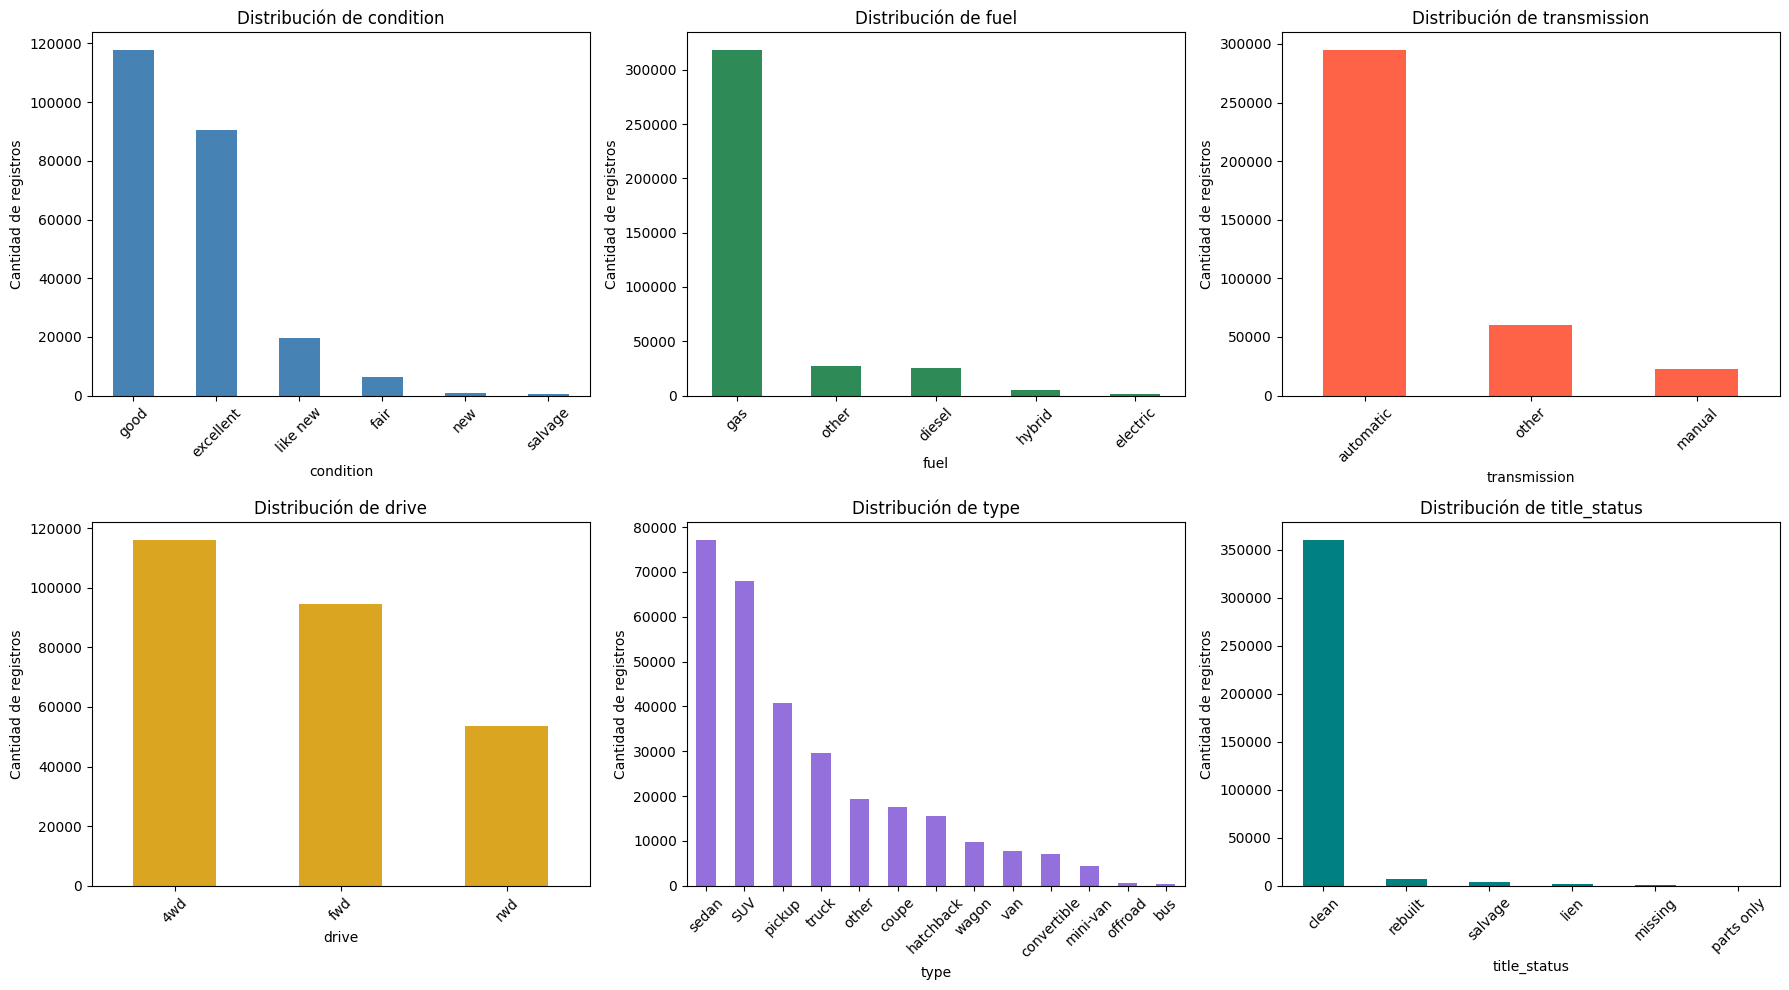

In [3]:
# Visualización
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

colores = ['steelblue', 'seagreen', 'tomato', 'goldenrod', 'mediumpurple', 'teal']

for i, col in enumerate(catCols):
    counts = dfFiltrado[col].value_counts(dropna=True)
    counts.plot(kind='bar', ax=axes[i], color=colores[i])
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_ylabel('Cantidad de registros')
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('desbalance_categorias.png', dpi=150)
plt.show()

In [4]:
# Simulación de filtros 
total = len(dfFiltrado)

# Filtro condition >= good
conditionBuena = dfFiltrado[dfFiltrado['condition'].isin(['good', 'excellent', 'like new'])]
print(f"Condition >= good: {len(conditionBuena):,} ({len(conditionBuena)/total*100:.2f}%)")

# Filtro fuel = gas
fuelGas = dfFiltrado[dfFiltrado['fuel'] == 'gas']
print(f"Fuel = gas: {len(fuelGas):,} ({len(fuelGas)/total*100:.2f}%)")

# Filtro transmission = automatic
auto = dfFiltrado[dfFiltrado['transmission'] == 'automatic']
print(f"Transmission = automatic: {len(auto):,} ({len(auto)/total*100:.2f}%)")

# Filtro title_status = clean
titleClean = dfFiltrado[dfFiltrado['title_status'] == 'clean']
print(f"Title status = clean: {len(titleClean):,} ({len(titleClean)/total*100:.2f}%)")

# Filtro type = SUV
suv = dfFiltrado[dfFiltrado['type'] == 'SUV']
print(f"Type = SUV: {len(suv):,} ({len(suv)/total*100:.2f}%)")

# Filtro combinado ejemplo cliente real
clienteEjemplo = dfFiltrado[
    (dfFiltrado['condition'].isin(['good', 'excellent', 'like new'])) &
    (dfFiltrado['fuel'] == 'gas') &
    (dfFiltrado['transmission'] == 'automatic') &
    (dfFiltrado['title_status'] == 'clean') &
    (dfFiltrado['price'] <= 15000)
]

print(f"\nValores del filtro:")
print(f"Condition - Buena")
print(f"Fuel - gas")
print(f"Transmission - automatic")
print(f"Tittle_status - clean")
print(f"Type - SUV")
print(f"Price <= 15 000")

print(f"\nFiltro cliente completo:")
print(f"{len(clienteEjemplo):,} registros ({len(clienteEjemplo)/total*100:.2f}%)")

Condition >= good: 228,040 (60.05%)
Fuel = gas: 318,492 (83.86%)
Transmission = automatic: 295,150 (77.72%)
Title status = clean: 360,300 (94.87%)
Type = SUV: 67,914 (17.88%)

Valores del filtro:
Condition - Buena
Fuel - gas
Transmission - automatic
Tittle_status - clean
Type - SUV
Price <= 15 000

Filtro cliente completo:
86,253 registros (22.71%)


In [5]:
# Reumen final del desbalance
print("\n--- Resumen de desbalance por categoria ---")
for col in catCols:
    counts = dfFiltrado[col].value_counts(dropna=True)
    pct = (counts / len(dfFiltrado) * 100).round(2)
    dominante = counts.index[0]
    print(f"{col}: '{dominante}' domina con {pct.iloc[0]}%")


--- Resumen de desbalance por categoria ---
condition: 'good' domina con 31.05%
fuel: 'gas' domina con 83.86%
transmission: 'automatic' domina con 77.72%
drive: '4wd' domina con 30.58%
type: 'sedan' domina con 20.32%
title_status: 'clean' domina con 94.87%
